# HATR memory management — River e CapyMOA

Questo notebook verifica il memory management di `HoeffdingAdaptiveTreeRegressor` con tre esperimenti per framework:

1. **control**: budget ampio, nessuna foglia deve essere disattivata per memoria;
2. **deactivate**: budget stretto, le foglie meno promettenti devono diventare inattive mentre la crescita resta consentita;
3. **stop_growth**: stesso budget stretto con `stop_mem_management=True`, quindi il modello deve bloccare la crescita anziché affidarsi alla normale selezione attiva/inattiva.

`merit_preprune=False` e `max_depth=None` isolano le disattivazioni dovute alla memoria. I budget di River e CapyMOA sono volutamente diversi: gli oggetti Python e Java hanno rappresentazioni e overhead differenti, quindi non ha senso confrontarli byte per byte.

## Setup: JAR HATR e SizeOf agent

CapyMOA può applicare il limite solo se la JVM parte con `sizeofag` come Java agent. Eseguire il notebook da un **kernel fresco**; se la JVM era già partita senza agent, riavviare il kernel.

In [1]:
import os
import sys
from pathlib import Path

import jpype
import jpype.config

jpype.config.destroy_jvm = False

cwd = Path.cwd().resolve()
PROJECT_DIR = cwd.parent if cwd.name == 'experiments' else cwd
IMPLEMENTATION_DIR = PROJECT_DIR / 'implementation'
HATR_JAR = (IMPLEMENTATION_DIR / 'hatr-moa' / 'target' /
            'hoeffding-adaptive-tree-regressor-moa-1.0-SNAPSHOT.jar')
SIZEOF_JAR = (Path.home() / '.m2' / 'repository' / 'com' / 'github' /
              'fracpete' / 'sizeofag' / '1.1.0' / 'sizeofag-1.1.0.jar')

assert HATR_JAR.exists(), (
    f'JAR HATR non trovato: {HATR_JAR}\n'
    'Compilare con: cd ../implementation/hatr-moa && mvn package -DskipTests'
)
assert SIZEOF_JAR.exists(), f'SizeOf agent non trovato: {SIZEOF_JAR}'

if not jpype.isJVMStarted():
    os.environ['CAPYMOA_JVM_ARGS'] = (
        f'-Xmx4g -Xss10M -javaagent:{SIZEOF_JAR} '
        '--add-opens=java.base/java.util=ALL-UNNAMED '
        '--add-opens=java.base/java.lang=ALL-UNNAMED '
        '--add-opens=java.base/java.lang.reflect=ALL-UNNAMED '
        '-XX:ErrorFile=/dev/null'
    )
    jpype.addClassPath(str(HATR_JAR))
else:
    print('JVM già avviata: verifico che SizeOf sia realmente attivo...')

sys.path.insert(0, str(IMPLEMENTATION_DIR))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from pympler import asizeof
from capymoa.instance import RegressionInstance
from capymoa.stream import Schema
from hatr_capymoa import HoeffdingAdaptiveTreeRegressor as CapyHATR
from moa.core import SizeOf as MoaSizeOf
from river import drift as river_drift
from river import tree as river_tree

probe = jpype.JClass('java.util.ArrayList')()
probe_size = int(MoaSizeOf.fullSizeOf(probe))
assert probe_size > 0, (
    'SizeOf agent non attivo. Riavviare il kernel ed eseguire Run All.'
)
print(f'Setup OK — SizeOf agent attivo (probe={probe_size} byte)')

Setup OK — SizeOf agent attivo (probe=40 byte)


## Dataset e configurazioni

Usiamo uno stream sintetico stazionario di 5.000 istanze. Un `grace_period` breve permette all'albero di creare abbastanza foglie da esercitare il limite. Il controllo usa 100 MB; il test stretto usa 0,5 MB in River e 0,1 MB in CapyMOA.

In [2]:
N_SAMPLES = 5_000
GRACE_PERIOD = 50
MEMORY_PERIOD = 100
SEED = 42

RIVER_TIGHT_MB = 0.5
CAPYMOA_TIGHT_MB = 0.1
WIDE_MB = 100.0

rng = np.random.RandomState(SEED)
X = rng.randn(N_SAMPLES, 3).astype(np.float64)
y = 2 * X[:, 0] + 3 * X[:, 1] - X[:, 2] + 0.1 * rng.randn(N_SAMPLES)
feature_names = ['x0', 'x1', 'x2']

schema = Schema.from_custom(
    features=[*feature_names, 'target'],
    target='target',
    name='memory_management_demo',
)

policies = {
    'control': {'tight': False, 'stop': False},
    'deactivate': {'tight': True, 'stop': False},
    'stop_growth': {'tight': True, 'stop': True},
}

print(f'{N_SAMPLES} campioni, grace_period={GRACE_PERIOD}, check ogni {MEMORY_PERIOD}')
print(f'Budget stretti: River={RIVER_TIGHT_MB} MB, CapyMOA={CAPYMOA_TIGHT_MB} MB')

5000 campioni, grace_period=50, check ogni 100
Budget stretti: River=0.5 MB, CapyMOA=0.1 MB


## Runner e misure

A ogni controllo registriamo dimensione reale del modello, struttura dell'albero e flag di crescita. La dimensione è misurata con Pympler in River e con `moa.core.SizeOf` in CapyMOA.

In [3]:
def river_structure(model):
    s = model.summary
    return {
        'nodes': int(s.get('n_nodes', 0)),
        'leaves': int(s.get('n_leaves', 0)),
        'active': int(s.get('n_active_leaves', 0)),
        'inactive': int(s.get('n_inactive_leaves', 0)),
        'growth_allowed': bool(model._growth_allowed),
        'model_mb': asizeof.asizeof(model) / (1024 ** 2),
    }


def capymoa_structure(model):
    m = {
        item.getName(): item.getValue()
        for item in model.moa_learner.getModelMeasurements()
    }
    return {
        'nodes': int(m.get('tree nodes', 0)),
        'leaves': int(m.get('tree leaves', 0)),
        'active': int(m.get('active leaves', 0)),
        'inactive': int(m.get('inactive leaves', 0)),
        'growth_allowed': bool(model.moa_learner.growthAllowed),
        'model_mb': MoaSizeOf.fullSizeOf(model.moa_learner) / (1024 ** 2),
    }


def build_river(policy):
    cfg = policies[policy]
    budget = RIVER_TIGHT_MB if cfg['tight'] else WIDE_MB
    model = river_tree.HoeffdingAdaptiveTreeRegressor(
        grace_period=GRACE_PERIOD,
        leaf_prediction='mean',
        bootstrap_sampling=False,
        merit_preprune=False,
        max_size=budget,
        memory_estimate_period=MEMORY_PERIOD,
        stop_mem_management=cfg['stop'],
        drift_detector=river_drift.ADWIN(delta=1e-10, clock=32),
        seed=0,
    )
    return model, budget


def build_capymoa(policy):
    cfg = policies[policy]
    budget = CAPYMOA_TIGHT_MB if cfg['tight'] else WIDE_MB
    model = CapyHATR(
        schema=schema,
        grace_period=GRACE_PERIOD,
        leaf_prediction='mean',
        bootstrap_sampling=False,
        merit_preprune=False,
        max_size_mb=budget,
        memory_estimate_period=MEMORY_PERIOD,
        stop_mem_management=cfg['stop'],
        adwin_delta=1e-10,
        random_seed=0,
    )
    return model, budget


def run_river(policy):
    model, budget = build_river(policy)
    rows = []
    for i in range(N_SAMPLES):
        x = {name: float(X[i, j]) for j, name in enumerate(feature_names)}
        model.learn_one(x, float(y[i]))
        if (i + 1) % MEMORY_PERIOD == 0:
            rows.append({
                'sample': i + 1, 'framework': 'River',
                'policy': policy, 'budget_mb': budget,
                **river_structure(model),
            })
    return rows


def run_capymoa(policy):
    model, budget = build_capymoa(policy)
    rows = []
    for i in range(N_SAMPLES):
        model.train(RegressionInstance(schema, (X[i], float(y[i]))))
        if (i + 1) % MEMORY_PERIOD == 0:
            rows.append({
                'sample': i + 1, 'framework': 'CapyMOA',
                'policy': policy, 'budget_mb': budget,
                **capymoa_structure(model),
            })
    return rows

In [4]:
records = []
for framework, runner in [('River', run_river), ('CapyMOA', run_capymoa)]:
    for policy in policies:
        print(f'Running {framework:8} / {policy:11} ...', end=' ')
        records.extend(runner(policy))
        print('done')

history = pd.DataFrame(records)
final = (history.sort_values('sample').groupby(['framework', 'policy'], as_index=False)
         .tail(1).sort_values(['framework', 'policy']))
final[['framework', 'policy', 'budget_mb', 'model_mb', 'nodes', 'leaves',
       'active', 'inactive', 'growth_allowed']]

Running River    / control     ... done
Running River    / deactivate  ... done
Running River    / stop_growth ... done
Running CapyMOA  / control     ... done
Running CapyMOA  / deactivate  ... done
Running CapyMOA  / stop_growth ... done


,framework,policy,budget_mb,model_mb,nodes,leaves,active,inactive,growth_allowed
199,CapyMOA,control,100.0,0.153366,75,38,50,0,True
249,CapyMOA,deactivate,0.1,0.102806,67,34,8,26,True
299,CapyMOA,stop_growth,0.1,0.152664,41,21,21,0,False
49,River,control,100.0,0.686874,75,38,50,0,True
99,River,deactivate,0.5,0.476089,69,35,19,16,True
149,River,stop_growth,0.5,0.686783,75,38,49,1,False


## Andamento della memoria e delle foglie inattive

Il budget è un limite periodico e best-effort: il controllo avviene ogni `memory_estimate_period` istanze e una parte strutturale del modello non può essere eliminata. Ci aspettiamo quindi una dimensione vicina al budget, non necessariamente identica al byte.

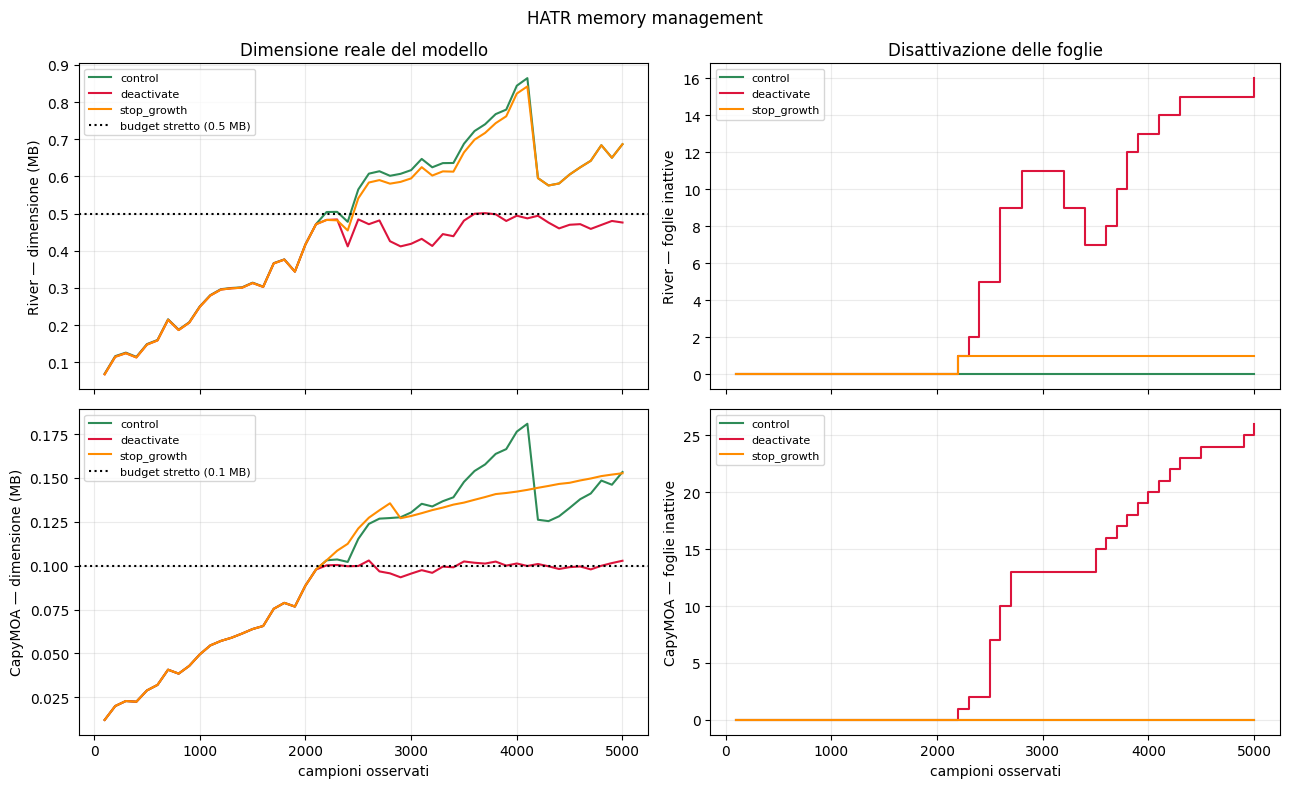

In [5]:
colors = {'control': 'seagreen', 'deactivate': 'crimson', 'stop_growth': 'darkorange'}
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex='col')

for row, framework in enumerate(['River', 'CapyMOA']):
    subset = history[history['framework'] == framework]
    for policy in policies:
        data = subset[subset['policy'] == policy]
        axes[row, 0].plot(data['sample'], data['model_mb'],
                          label=policy, color=colors[policy])
        axes[row, 1].step(data['sample'], data['inactive'], where='post',
                          label=policy, color=colors[policy])

    tight_budget = RIVER_TIGHT_MB if framework == 'River' else CAPYMOA_TIGHT_MB
    axes[row, 0].axhline(tight_budget, color='black', linestyle=':',
                            label=f'budget stretto ({tight_budget} MB)')
    axes[row, 0].set_ylabel(f'{framework} — dimensione (MB)')
    axes[row, 1].set_ylabel(f'{framework} — foglie inattive')
    for ax in axes[row]:
        ax.grid(alpha=0.25)
        ax.legend(fontsize=8)

axes[0, 0].set_title('Dimensione reale del modello')
axes[0, 1].set_title('Disattivazione delle foglie')
axes[1, 0].set_xlabel('campioni osservati')
axes[1, 1].set_xlabel('campioni osservati')
fig.suptitle('HATR memory management')
fig.tight_layout()
plt.show()

## Verifiche automatiche

Le verifiche sono qualitative e coerenti con le diverse rappresentazioni in memoria:

- il controllo ampio non deve avere foglie inattive;
- il limite stretto deve produrre almeno una foglia inattiva e mantenere `growth_allowed=True`;
- il modello ristretto deve occupare meno del controllo;
- `stop_growth` deve portare `growth_allowed=False`.

In [6]:
checks = []
for framework in ['River', 'CapyMOA']:
    rows = final[final['framework'] == framework].set_index('policy')

    framework_checks = {
        'control: inactive == 0': rows.loc['control', 'inactive'] == 0,
        'deactivate: inactive > 0': rows.loc['deactivate', 'inactive'] > 0,
        'deactivate: growth continua': bool(rows.loc['deactivate', 'growth_allowed']),
        'deactivate: modello più piccolo': (
            rows.loc['deactivate', 'model_mb'] < rows.loc['control', 'model_mb']
        ),
        'stop_growth: crescita bloccata': not bool(rows.loc['stop_growth', 'growth_allowed']),
    }
    for check, passed in framework_checks.items():
        checks.append({'framework': framework, 'check': check, 'passed': bool(passed)})

checks_df = pd.DataFrame(checks)
display(checks_df)
assert checks_df['passed'].all(), checks_df[~checks_df['passed']]
print('OK: tutti i controlli di memory management sono superati.')

,framework,check,passed
0,River,control: inactive == 0,True
1,River,deactivate: inactive > 0,True
2,River,deactivate: growth continua,True
3,River,deactivate: modello più piccolo,True
4,River,stop_growth: crescita bloccata,True
5,CapyMOA,control: inactive == 0,True
6,CapyMOA,deactivate: inactive > 0,True
7,CapyMOA,deactivate: growth continua,True
8,CapyMOA,deactivate: modello più piccolo,True
9,CapyMOA,stop_growth: crescita bloccata,True


OK: tutti i controlli di memory management sono superati.


## Conclusione

Il memory management funziona in entrambi i framework: con budget ampio l'albero cresce senza foglie inattive; con budget stretto vengono rimossi gli attribute observer delle foglie meno promettenti e la dimensione si riduce; con `stop_mem_management=True` viene invece disabilitata la crescita. Il numero esatto di foglie disattivate non deve coincidere tra River e CapyMOA, perché il costo in byte di una foglia Python è diverso da quello della corrispondente struttura Java.